In [1]:
!pip install -q "tacoreader<1.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 72.8 MB/s eta 0:00:00:00:0100:01


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import rasterio

from skimage.metrics import structural_similarity as ssim

import tacoreader.v1 as tacoreader

print("PyTorch:", torch.__version__)
print("TACO:", tacoreader.__version__)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

PyTorch: 2.10.0+cu128
TACO: 0.6.5
Device: cuda


In [3]:
dataset = tacoreader.load(
    "tacofoundation:sen2naipv2-unet"
)

print("SEN2NAIPv2 loaded")

SEN2NAIPv2 loaded


In [4]:
sample_idx = 0

lr_path = dataset.read(
    sample_idx
).read(0)

hr_path = dataset.read(
    sample_idx
).read(1)

with rasterio.open(lr_path) as src:
    lr = src.read().astype("float32")

with rasterio.open(hr_path) as src:
    hr = src.read().astype("float32")

print("LR shape:", lr.shape)
print("HR shape:", hr.shape)

print(
    "LR range:",
    lr.min(),
    lr.max()
)

print(
    "HR range:",
    hr.min(),
    hr.max()
)

LR shape: (4, 130, 130)
HR shape: (4, 520, 520)
LR range: 116.0 4608.0
HR range: 32.0 5032.0


In [6]:
train_pairs = []

NUM_TRAIN = 150
failed_samples = []

for i in range(NUM_TRAIN):

    try:

        lr_path = dataset.read(i).read(0)
        hr_path = dataset.read(i).read(1)

        with rasterio.open(lr_path) as src:
            lr = src.read().astype("float32")

        with rasterio.open(hr_path) as src:
            hr = src.read().astype("float32")

        # Check shapes
        if lr.shape != (4, 130, 130):
            raise ValueError(
                f"Unexpected LR shape: {lr.shape}"
            )

        if hr.shape != (4, 520, 520):
            raise ValueError(
                f"Unexpected HR shape: {hr.shape}"
            )

        # Normalize
        lr = lr / 3000.0
        hr = hr / 3000.0

        train_pairs.append(
            (lr, hr)
        )

        if len(train_pairs) % 10 == 0:
            print(
                f"Loaded {len(train_pairs)} valid samples"
            )

    except Exception as e:

        failed_samples.append(i)

        print(
            f"Skipping sample {i}: {e}"
        )

print()
print("========== LOADING COMPLETE ==========")
print("Valid training samples:", len(train_pairs))
print("Failed samples:", failed_samples)

Loaded 10 valid samples
Loaded 20 valid samples
Loaded 30 valid samples
Loaded 40 valid samples
Loaded 50 valid samples
Loaded 60 valid samples
Loaded 70 valid samples
Loaded 80 valid samples
Loaded 90 valid samples
Loaded 100 valid samples
Loaded 110 valid samples
Loaded 120 valid samples
Loaded 130 valid samples
Loaded 140 valid samples
Loaded 150 valid samples

========== LOADING COMPLETE ==========
Valid training samples: 150
Failed samples: []


In [7]:
def make_patch(
    lr,
    hr,
    patch_size=32
):

    lr_h, lr_w = lr.shape[1:]

    y = np.random.randint(
        0,
        lr_h - patch_size + 1
    )

    x = np.random.randint(
        0,
        lr_w - patch_size + 1
    )

    lr_patch = lr[
        :,
        y:y + patch_size,
        x:x + patch_size
    ]

    hr_y = y * 4
    hr_x = x * 4

    hr_patch = hr[
        :,
        hr_y:hr_y + patch_size * 4,
        hr_x:hr_x + patch_size * 4
    ]

    return lr_patch, hr_patch

In [8]:
lr_patch, hr_patch = make_patch(
    train_pairs[0][0],
    train_pairs[0][1],
    patch_size=32
)

print(
    "LR patch:",
    lr_patch.shape
)

print(
    "HR patch:",
    hr_patch.shape
)

LR patch: (4, 32, 32)
HR patch: (4, 128, 128)


In [9]:
class RCAB(nn.Module):

    def __init__(
        self,
        channels=96,
        reduction=8
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        self.conv2 = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        self.avg_pool = (
            nn.AdaptiveAvgPool2d(1)
        )

        self.attention = nn.Sequential(

            nn.Conv2d(
                channels,
                channels // reduction,
                1
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(
                channels // reduction,
                channels,
                1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):

        residual = x

        out = self.conv1(x)

        out = self.relu(out)

        out = self.conv2(out)

        weights = self.avg_pool(out)

        weights = self.attention(
            weights
        )

        out = out * weights

        out = 0.1 * out

        out = out + residual

        return out

In [10]:
def window_partition(
    x,
    window_size
):

    B, H, W, C = x.shape

    x = x.view(
        B,
        H // window_size,
        window_size,
        W // window_size,
        window_size,
        C
    )

    windows = x.permute(
        0,
        1,
        3,
        2,
        4,
        5
    ).contiguous()

    windows = windows.view(
        -1,
        window_size,
        window_size,
        C
    )

    return windows

In [11]:
def window_reverse(
    windows,
    window_size,
    H,
    W
):

    B = int(
        windows.shape[0]
        / (H * W / window_size / window_size)
    )

    x = windows.view(
        B,
        H // window_size,
        W // window_size,
        window_size,
        window_size,
        -1
    )

    x = x.permute(
        0,
        1,
        3,
        2,
        4,
        5
    ).contiguous()

    x = x.view(
        B,
        H,
        W,
        -1
    )

    return x

In [12]:
class SwinBlock(nn.Module):

    def __init__(
        self,
        dim=96,
        num_heads=8,
        window_size=8,
        shift_size=0,
        mlp_ratio=4.0
    ):
        super().__init__()

        self.dim = dim
        self.window_size = window_size
        self.shift_size = shift_size

        self.norm1 = nn.LayerNorm(dim)

        self.attention = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            batch_first=True
        )

        hidden_dim = int(
            dim * mlp_ratio
        )

        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(

            nn.Linear(
                dim,
                hidden_dim
            ),

            nn.GELU(),

            nn.Linear(
                hidden_dim,
                dim
            )
        )

    def forward(self, x):

        B, C, H, W = x.shape

        ws = self.window_size

        # Convert to channels-last
        shortcut = x

        x = x.permute(
            0,
            2,
            3,
            1
        )

        # Padding
        pad_h = (
            ws - H % ws
        ) % ws

        pad_w = (
            ws - W % ws
        ) % ws

        if pad_h or pad_w:

            x = F.pad(
                x,
                (0, 0, 0, pad_w, 0, pad_h)
            )

        Hp = x.shape[1]
        Wp = x.shape[2]

        # Shifted window
        if self.shift_size > 0:

            x = torch.roll(
                x,
                shifts=(
                    -self.shift_size,
                    -self.shift_size
                ),
                dims=(1, 2)
            )

        # Partition windows
        windows = window_partition(
            x,
            ws
        )

        windows = windows.view(
            -1,
            ws * ws,
            C
        )

        # Attention
        shortcut_windows = windows

        windows = self.norm1(
            windows
        )

        attended, _ = self.attention(
            windows,
            windows,
            windows
        )

        windows = (
            shortcut_windows
            + attended
        )

        # MLP
        windows = (
            windows
            + self.mlp(
                self.norm2(windows)
            )
        )

        # Reverse windows
        windows = windows.view(
            -1,
            ws,
            ws,
            C
        )

        x = window_reverse(
            windows,
            ws,
            Hp,
            Wp
        )

        # Reverse shift
        if self.shift_size > 0:

            x = torch.roll(
                x,
                shifts=(
                    self.shift_size,
                    self.shift_size
                ),
                dims=(1, 2)
            )

        # Remove padding
        x = x[:, :H, :W, :]

        # Back to channels-first
        x = x.permute(
            0,
            3,
            1,
            2
        )

        # Residual
        x = shortcut + 0.1 * (
            x - shortcut
        )

        return x

In [13]:
class SwinIRBlock(nn.Module):

    def __init__(
        self,
        channels=96,
        depth=6,
        num_heads=8,
        window_size=8
    ):
        super().__init__()

        blocks = []

        for i in range(depth):

            shift = (
                0
                if i % 2 == 0
                else window_size // 2
            )

            blocks.append(
                SwinBlock(
                    dim=channels,
                    num_heads=num_heads,
                    window_size=window_size,
                    shift_size=shift
                )
            )

        self.blocks = nn.Sequential(
            *blocks
        )

        self.conv = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

    def forward(self, x):

        residual = x

        x = self.blocks(x)

        x = self.conv(x)

        x = x + residual

        return x

In [14]:
class RCAN_SwinIR(nn.Module):

    def __init__(
        self,
        rcan_blocks=12,
        swin_depth=6,
        channels=96
    ):
        super().__init__()

        # Input
        self.head = nn.Conv2d(
            4,
            channels,
            3,
            padding=1
        )

        # RCAN
        self.rcan_body = nn.Sequential(
            *[
                RCAB(channels)
                for _ in range(rcan_blocks)
            ]
        )

        self.rcan_conv = nn.Conv2d(
            channels,
            channels,
            3,
            padding=1
        )

        # SwinIR
        self.swin_body = SwinIRBlock(
            channels=channels,
            depth=swin_depth,
            num_heads=8,
            window_size=8
        )

        # Fusion
        self.fusion = nn.Conv2d(
            channels * 2,
            channels,
            3,
            padding=1
        )

        # ×2
        self.up1 = nn.Sequential(

            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),

            nn.PixelShuffle(2),

            nn.ReLU(
                inplace=True
            )
        )

        # ×2
        self.up2 = nn.Sequential(

            nn.Conv2d(
                channels,
                channels * 4,
                3,
                padding=1
            ),

            nn.PixelShuffle(2),

            nn.ReLU(
                inplace=True
            )
        )

        # 4-band output
        self.tail = nn.Conv2d(
            channels,
            4,
            3,
            padding=1
        )

    def forward(self, x):

        # Shallow features
        shallow = self.head(x)

        # RCAN branch
        rcan = self.rcan_body(
            shallow
        )

        rcan = self.rcan_conv(
            rcan
        )

        rcan = rcan + shallow

        # SwinIR branch
        swin = self.swin_body(
            rcan
        )

        # Fuse
        combined = torch.cat(
            [rcan, swin],
            dim=1
        )

        combined = self.fusion(
            combined
        )

        combined = combined + shallow

        # Upsample ×4
        combined = self.up1(
            combined
        )

        combined = self.up2(
            combined
        )

        # Output
        output = self.tail(
            combined
        )

        return output

In [15]:
model = RCAN_SwinIR(
    rcan_blocks=12,
    swin_depth=6,
    channels=96
).to(device)

print("RCAN + SwinIR created")

print(
    "Parameters:",
    sum(
        p.numel()
        for p in model.parameters()
    )
)

RCAN + SwinIR created
Parameters: 3696340


In [16]:
x = torch.tensor(
    lr_patch,
    dtype=torch.float32
).unsqueeze(0).to(device)

y = torch.tensor(
    hr_patch,
    dtype=torch.float32
).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():

    output = model(x)

print("Input :", x.shape)
print("Output:", output.shape)
print("Target:", y.shape)

Input : torch.Size([1, 4, 32, 32])
Output: torch.Size([1, 4, 128, 128])
Target: torch.Size([1, 4, 128, 128])


In [17]:
class CharbonnierLoss(nn.Module):

    def __init__(self, epsilon=1e-3):
        super().__init__()
        self.epsilon = epsilon

    def forward(self, pred, target):

        diff = pred - target

        return torch.mean(
            torch.sqrt(
                diff ** 2 + self.epsilon ** 2
            )
        )


pixel_loss = CharbonnierLoss()


def gradient_loss(pred, target):

    pred_x = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    target_x = target[:, :, :, 1:] - target[:, :, :, :-1]

    pred_y = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    target_y = target[:, :, 1:, :] - target[:, :, :-1, :]

    loss_x = torch.mean(
        torch.abs(pred_x - target_x)
    )

    loss_y = torch.mean(
        torch.abs(pred_y - target_y)
    )

    return loss_x + loss_y


def spectral_angle_loss(pred, target):

    pred = pred.permute(
        0, 2, 3, 1
    ).reshape(-1, 4)

    target = target.permute(
        0, 2, 3, 1
    ).reshape(-1, 4)

    pred = F.normalize(
        pred,
        p=2,
        dim=1,
        eps=1e-8
    )

    target = F.normalize(
        target,
        p=2,
        dim=1,
        eps=1e-8
    )

    cosine = torch.sum(
        pred * target,
        dim=1
    )

    cosine = torch.clamp(
        cosine,
        -1 + 1e-7,
        1 - 1e-7
    )

    angle = torch.acos(cosine)

    return angle.mean()


print("All losses ready")

All losses ready


In [18]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30,
    eta_min=1e-6
)

print("Optimizer ready")

Optimizer ready


In [19]:
EPOCHS = 30
PATCHES_PER_EPOCH = 400

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0
    total_pixel = 0
    total_edge = 0
    total_spectral = 0

    for step in range(PATCHES_PER_EPOCH):

        idx = np.random.randint(
            len(train_pairs)
        )

        lr, hr = train_pairs[idx]

        lr_patch, hr_patch = make_patch(
            lr,
            hr,
            patch_size=32
        )

        lr_tensor = torch.tensor(
            lr_patch,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        hr_tensor = torch.tensor(
            hr_patch,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        prediction = model(
            lr_tensor
        )

        pixel = pixel_loss(
            prediction,
            hr_tensor
        )

        edge = gradient_loss(
            prediction,
            hr_tensor
        )

        spectral = spectral_angle_loss(
            prediction,
            hr_tensor
        )

        # Pixel fidelity remains dominant
        loss = (
            1.00 * pixel
            + 0.10 * edge
            + 0.05 * spectral
        )

        optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()
        total_pixel += pixel.item()
        total_edge += edge.item()
        total_spectral += spectral.item()

    scheduler.step()

    n = PATCHES_PER_EPOCH

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Loss {total_loss/n:.5f} | "
        f"Pixel {total_pixel/n:.5f} | "
        f"Edge {total_edge/n:.5f} | "
        f"SAM {total_spectral/n:.5f} | "
        f"LR {scheduler.get_last_lr()[0]:.2e}"
    )

Epoch 01/30 | Loss 0.10158 | Pixel 0.08605 | Edge 0.09409 | SAM 0.12260 | LR 9.97e-05
Epoch 02/30 | Loss 0.05943 | Pixel 0.04871 | Edge 0.07799 | SAM 0.05848 | LR 9.89e-05
Epoch 03/30 | Loss 0.05589 | Pixel 0.04537 | Edge 0.07825 | SAM 0.05388 | LR 9.76e-05
Epoch 04/30 | Loss 0.05082 | Pixel 0.04110 | Edge 0.07396 | SAM 0.04658 | LR 9.57e-05
Epoch 05/30 | Loss 0.05191 | Pixel 0.04194 | Edge 0.07562 | SAM 0.04817 | LR 9.34e-05
Epoch 06/30 | Loss 0.04953 | Pixel 0.04006 | Edge 0.07300 | SAM 0.04343 | LR 9.05e-05
Epoch 07/30 | Loss 0.04838 | Pixel 0.03900 | Edge 0.07317 | SAM 0.04123 | LR 8.73e-05
Epoch 08/30 | Loss 0.04787 | Pixel 0.03857 | Edge 0.07244 | SAM 0.04116 | LR 8.36e-05
Epoch 09/30 | Loss 0.04705 | Pixel 0.03785 | Edge 0.07238 | SAM 0.03917 | LR 7.96e-05
Epoch 10/30 | Loss 0.04730 | Pixel 0.03805 | Edge 0.07357 | SAM 0.03779 | LR 7.52e-05
Epoch 11/30 | Loss 0.04791 | Pixel 0.03845 | Edge 0.07530 | SAM 0.03866 | LR 7.06e-05
Epoch 12/30 | Loss 0.04627 | Pixel 0.03712 | Edge 0.07

In [20]:
test_pairs = []

TEST_START = 150
TEST_END = 160

for i in range(
    TEST_START,
    TEST_END
):

    lr_path = dataset.read(i).read(0)
    hr_path = dataset.read(i).read(1)

    with rasterio.open(lr_path) as src:
        lr = src.read().astype("float32")

    with rasterio.open(hr_path) as src:
        hr = src.read().astype("float32")

    lr = lr / 3000.0
    hr = hr / 3000.0

    test_pairs.append(
        (lr, hr)
    )

print(
    "Unseen test pairs:",
    len(test_pairs)
)

Unseen test pairs: 10


In [21]:
model.eval()

predictions = []
targets = []

with torch.no_grad():

    for lr, hr in test_pairs:

        x = torch.tensor(
            lr,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        sr = model(x)

        predictions.append(
            sr.cpu().numpy()[0]
        )

        targets.append(hr)

predictions = np.stack(
    predictions
)

targets = np.stack(
    targets
)

print(
    "Predictions:",
    predictions.shape
)

print(
    "Targets:",
    targets.shape
)

Predictions: (10, 4, 520, 520)
Targets: (10, 4, 520, 520)


In [22]:
mse = np.mean(
    (predictions - targets) ** 2
)

rmse = np.sqrt(mse)

psnr = 10 * np.log10(
    1 / (mse + 1e-10)
)

print(
    f"RMSE : {rmse:.5f}"
)

print(
    f"PSNR : {psnr:.3f} dB"
)

RMSE : 0.06577
PSNR : 23.639 dB


In [23]:
ssim_scores = []

for i in range(
    len(targets)
):

    score = ssim(
        targets[i].transpose(1, 2, 0),
        predictions[i].transpose(1, 2, 0),
        channel_axis=2,
        data_range=1
    )

    ssim_scores.append(score)

mean_ssim = np.mean(
    ssim_scores
)

print(
    f"SSIM : {mean_ssim:.4f}"
)

SSIM : 0.7019


In [24]:
print("========== RCAN + SWINIR ==========")
print(f"RMSE : {rmse:.5f}")
print(f"PSNR : {psnr:.3f} dB")
print(f"SSIM : {mean_ssim:.4f}")

========== RCAN + SWINIR ==========
RMSE : 0.06577
PSNR : 23.639 dB
SSIM : 0.7019


In [25]:
print("=" * 60)
print("             FULL MODEL COMPARISON")
print("=" * 60)

print("""
1. RCAN BASELINE
   Architecture:
   - RCAN
   - 12 RCAB
   - 96 channels
   - Channel Attention

   Loss:
   - Reconstruction

   RMSE : 0.05746
   PSNR : 24.813 dB
   SSIM : 0.6793
""")

print("""
2. IMPROVED RCAN 🏆 CURRENT BEST
   Architecture:
   - RCAN
   - 12 RCAB
   - 96 channels
   - Channel Attention

   Loss:
   - Charbonnier
   - Edge / Gradient
   - Spectral Angle

   Training:
   - AdamW
   - Cosine Annealing

   RMSE : 0.05542
   PSNR : 25.127 dB
   SSIM : 0.6908
""")

print("""
3. RCAN + HAT
   Architecture:
   - RCAN
   - HAT
   - Window Self-Attention
   - Channel Attention

   Loss:
   - Charbonnier
   - SSIM
   - Edge
   - Spectral Angle
   - VGG Perceptual

   RMSE : 0.06555
   PSNR : 23.669 dB
   SSIM : 0.7048
""")

print("""
4. RCAN + HAT v2
   Architecture:
   - RCAN
   - HAT
   - Window Self-Attention
   - Channel Attention

   Loss:
   - Charbonnier
   - SSIM
   - Edge
   - Spectral Angle
   - NO VGG

   RMSE : 0.06546
   PSNR : 23.680 dB
   SSIM : 0.7061
""")

print("""
5. RCAN + SWINIR
   Architecture:
   - RCAN
   - SwinIR
   - Window Attention
   - Shifted-Window Attention
   - 12 RCAB
   - 96 channels

   Loss:
   - Charbonnier
   - Edge / Gradient
   - Spectral Angle
   - NO VGG
   - NO perceptual loss

   RMSE : {:.5f}
   PSNR : {:.3f} dB
   SSIM : {:.4f}
""".format(
    rmse,
    psnr,
    mean_ssim
))

print("=" * 60)

             FULL MODEL COMPARISON

1. RCAN BASELINE
   Architecture:
   - RCAN
   - 12 RCAB
   - 96 channels
   - Channel Attention

   Loss:
   - Reconstruction

   RMSE : 0.05746
   PSNR : 24.813 dB
   SSIM : 0.6793


2. IMPROVED RCAN 🏆 CURRENT BEST
   Architecture:
   - RCAN
   - 12 RCAB
   - 96 channels
   - Channel Attention

   Loss:
   - Charbonnier
   - Edge / Gradient
   - Spectral Angle

   Training:
   - AdamW
   - Cosine Annealing

   RMSE : 0.05542
   PSNR : 25.127 dB
   SSIM : 0.6908


3. RCAN + HAT
   Architecture:
   - RCAN
   - HAT
   - Window Self-Attention
   - Channel Attention

   Loss:
   - Charbonnier
   - SSIM
   - Edge
   - Spectral Angle
   - VGG Perceptual

   RMSE : 0.06555
   PSNR : 23.669 dB
   SSIM : 0.7048


4. RCAN + HAT v2
   Architecture:
   - RCAN
   - HAT
   - Window Self-Attention
   - Channel Attention

   Loss:
   - Charbonnier
   - SSIM
   - Edge
   - Spectral Angle
   - NO VGG

   RMSE : 0.06546
   PSNR : 23.680 dB
   SSIM : 0.7061


5. RCAN +

In [26]:
models = {
    "RCAN Baseline": {
        "RMSE": 0.05746,
        "PSNR": 24.813,
        "SSIM": 0.6793
    },

    "Improved RCAN": {
        "RMSE": 0.05542,
        "PSNR": 25.127,
        "SSIM": 0.6908
    },

    "RCAN + HAT": {
        "RMSE": 0.06555,
        "PSNR": 23.669,
        "SSIM": 0.7048
    },

    "RCAN + HAT v2": {
        "RMSE": 0.06546,
        "PSNR": 23.680,
        "SSIM": 0.7061
    },

    "RCAN + SwinIR": {
        "RMSE": rmse,
        "PSNR": psnr,
        "SSIM": mean_ssim
    }
}

best_psnr = max(
    models,
    key=lambda x: models[x]["PSNR"]
)

best_ssim = max(
    models,
    key=lambda x: models[x]["SSIM"]
)

best_rmse = min(
    models,
    key=lambda x: models[x]["RMSE"]
)

print("Best PSNR :", best_psnr)
print("Best SSIM :", best_ssim)
print("Best RMSE :", best_rmse)

Best PSNR : Improved RCAN
Best SSIM : RCAN + HAT v2
Best RMSE : Improved RCAN


In [28]:
def stretch_rgb(img):

    # B04, B03, B02 → RGB
    rgb = img[:3].transpose(1, 2, 0)

    output = np.zeros_like(rgb)

    for c in range(3):

        low = np.percentile(
            rgb[:, :, c],
            2
        )

        high = np.percentile(
            rgb[:, :, c],
            98
        )

        output[:, :, c] = np.clip(
            (rgb[:, :, c] - low) /
            (high - low + 1e-8),
            0,
            1
        )

    return output

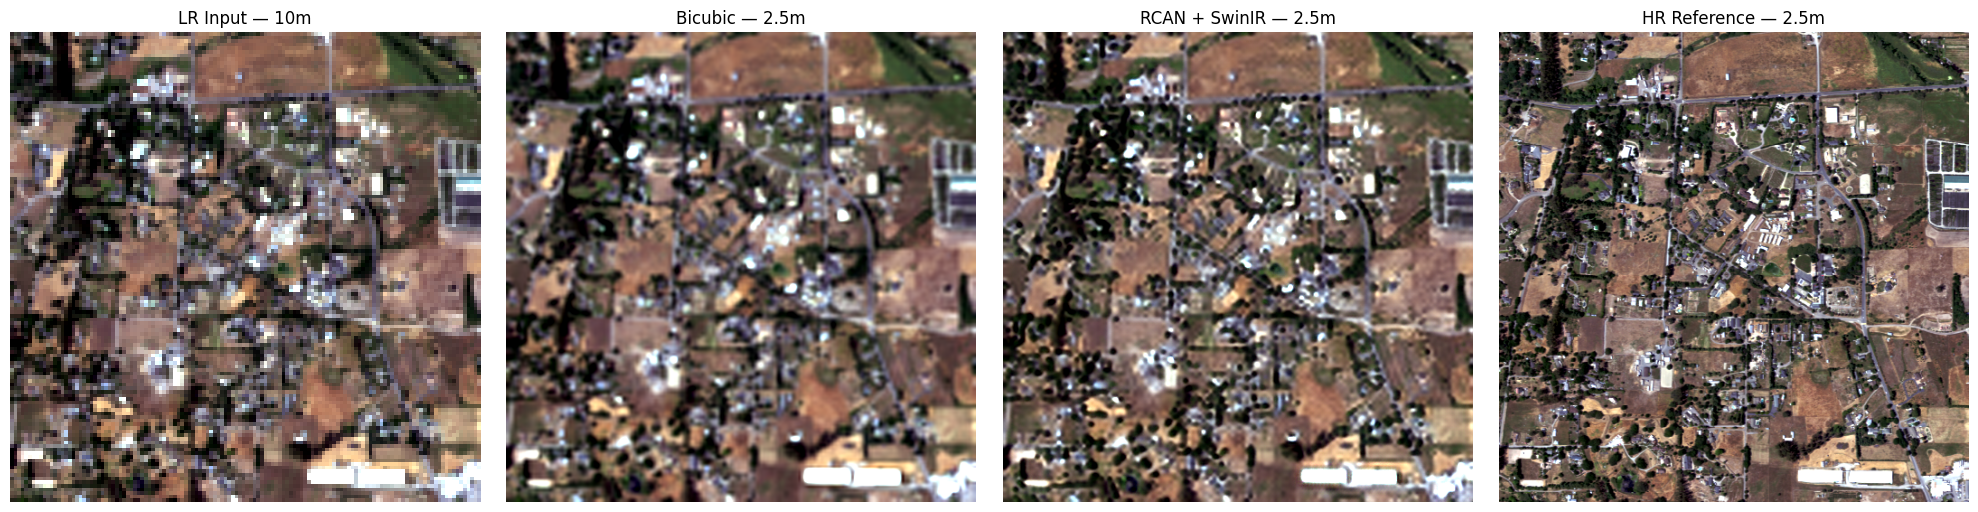

In [29]:
i = 0

lr = test_pairs[i][0]
hr = targets[i]
sr = predictions[i]

lr_tensor = torch.tensor(
    lr,
    dtype=torch.float32
).unsqueeze(0)

bicubic = F.interpolate(
    lr_tensor,
    size=hr.shape[-2:],
    mode="bicubic",
    align_corners=False
)[0].numpy()

plt.figure(figsize=(20, 5))

plt.subplot(1, 4, 1)
plt.imshow(stretch_rgb(lr))
plt.title("LR Input — 10m")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(stretch_rgb(bicubic))
plt.title("Bicubic — 2.5m")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(stretch_rgb(sr))
plt.title("RCAN + SwinIR — 2.5m")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(stretch_rgb(hr))
plt.title("HR Reference — 2.5m")
plt.axis("off")

plt.tight_layout()
plt.show()

In [42]:
def window_partition(x, window_size):
    B, H, W, C = x.shape

    x = x.view(
        B,
        H // window_size,
        window_size,
        W // window_size,
        window_size,
        C
    )

    windows = x.permute(
        0, 1, 3, 2, 4, 5
    ).contiguous()

    return windows.view(
        -1,
        window_size,
        window_size,
        C
    )


def window_reverse(windows, window_size, H, W):

    B = int(
        windows.shape[0]
        / ((H * W) / (window_size ** 2))
    )

    x = windows.view(
        B,
        H // window_size,
        W // window_size,
        window_size,
        window_size,
        -1
    )

    x = x.permute(
        0, 1, 3, 2, 4, 5
    ).contiguous()

    return x.view(
        B,
        H,
        W,
        -1
    )

In [43]:
class WindowAttention(nn.Module):

    def __init__(
        self,
        dim,
        num_heads=8
    ):
        super().__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            batch_first=True
        )

    def forward(self, x):

        output, _ = self.attention(
            x, x, x
        )

        return output

In [44]:
class SwinTransformerBlock(nn.Module):

    def __init__(
        self,
        dim=96,
        num_heads=8,
        window_size=8,
        shift_size=0,
        mlp_ratio=4.0
    ):
        super().__init__()

        self.window_size = window_size
        self.shift_size = shift_size

        self.norm1 = nn.LayerNorm(dim)

        self.attention = WindowAttention(
            dim,
            num_heads
        )

        hidden_dim = int(
            dim * mlp_ratio
        )

        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, dim)
        )

    def forward(self, x):

        B, C, H, W = x.shape

        ws = self.window_size

        shortcut = x

        x = x.permute(
            0, 2, 3, 1
        )

        pad_h = (ws - H % ws) % ws
        pad_w = (ws - W % ws) % ws

        if pad_h or pad_w:
            x = F.pad(
                x,
                (0, 0, 0, pad_w, 0, pad_h)
            )

        Hp, Wp = x.shape[1:3]

        if self.shift_size > 0:
            x = torch.roll(
                x,
                shifts=(
                    -self.shift_size,
                    -self.shift_size
                ),
                dims=(1, 2)
            )

        windows = window_partition(
            x,
            ws
        )

        windows = windows.view(
            -1,
            ws * ws,
            C
        )

        residual = windows

        windows = self.norm1(windows)

        windows = self.attention(
            windows
        )

        windows = residual + windows

        windows = (
            windows
            + self.mlp(
                self.norm2(windows)
            )
        )

        windows = windows.view(
            -1,
            ws,
            ws,
            C
        )

        x = window_reverse(
            windows,
            ws,
            Hp,
            Wp
        )

        if self.shift_size > 0:
            x = torch.roll(
                x,
                shifts=(
                    self.shift_size,
                    self.shift_size
                ),
                dims=(1, 2)
            )

        x = x[:, :H, :W, :]

        x = x.permute(
            0, 3, 1, 2
        )

        return shortcut + 0.1 * (
            x - shortcut
        )

In [48]:
class SwinIRGroup(nn.Module):

    def __init__(
        self,
        dim=96,
        depth=6,
        num_heads=8,
        window_size=8
    ):
        super().__init__()

        blocks = []

        for i in range(depth):

            shift_size = (
                0
                if i % 2 == 0
                else window_size // 2
            )

            blocks.append(
                SwinTransformerBlock(
                    dim=dim,
                    num_heads=num_heads,
                    window_size=window_size,
                    shift_size=shift_size
                )
            )

        self.blocks = nn.Sequential(
            *blocks
        )

        self.conv = nn.Conv2d(
            dim,
            dim,
            3,
            padding=1
        )

    def forward(self, x):

        residual = x

        x = self.blocks(x)

        x = self.conv(x)

        return x + residual

In [45]:
class SwinIR(nn.Module):

    def __init__(
        self,
        in_channels=4,
        out_channels=4,
        embed_dim=96,
        depth=6,
        num_heads=8,
        window_size=8
    ):
        super().__init__()

        self.head = nn.Conv2d(
            in_channels,
            embed_dim,
            3,
            padding=1
        )

        self.body = SwinIRGroup(
            dim=embed_dim,
            depth=depth,
            num_heads=num_heads,
            window_size=window_size
        )

        self.body_conv = nn.Conv2d(
            embed_dim,
            embed_dim,
            3,
            padding=1
        )

        self.up1 = nn.Sequential(
            nn.Conv2d(
                embed_dim,
                embed_dim * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.GELU()
        )

        self.up2 = nn.Sequential(
            nn.Conv2d(
                embed_dim,
                embed_dim * 4,
                3,
                padding=1
            ),
            nn.PixelShuffle(2),
            nn.GELU()
        )

        self.tail = nn.Conv2d(
            embed_dim,
            out_channels,
            3,
            padding=1
        )

    def forward(self, x):

        shallow = self.head(x)

        body = self.body(shallow)

        body = self.body_conv(body)

        body = body + shallow

        body = self.up1(body)
        body = self.up2(body)

        return self.tail(body)

In [49]:
swinir_model = SwinIR(
    in_channels=4,
    out_channels=4,
    embed_dim=96,
    depth=6,
    num_heads=8,
    window_size=8
).to(device)

print("Standalone SwinIR created")

print(
    "Parameters:",
    sum(
        p.numel()
        for p in swinir_model.parameters()
    )
)

Standalone SwinIR created
Parameters: 1508452


In [50]:
x = torch.tensor(
    lr_patch,
    dtype=torch.float32
).unsqueeze(0).to(device)

y = torch.tensor(
    hr_patch,
    dtype=torch.float32
).unsqueeze(0).to(device)

swinir_model.eval()

with torch.no_grad():

    output = swinir_model(x)

print("Input :", x.shape)
print("Output:", output.shape)
print("Target:", y.shape)

Input : torch.Size([1, 4, 32, 32])
Output: torch.Size([1, 4, 128, 128])
Target: torch.Size([1, 4, 128, 128])


In [51]:
class CharbonnierLoss(nn.Module):

    def __init__(
        self,
        epsilon=1e-3
    ):
        super().__init__()

        self.epsilon = epsilon

    def forward(
        self,
        prediction,
        target
    ):

        diff = prediction - target

        return torch.mean(
            torch.sqrt(
                diff ** 2
                + self.epsilon ** 2
            )
        )


swin_pixel_loss = CharbonnierLoss()


def swin_gradient_loss(
    pred,
    target
):

    pred_x = (
        pred[:, :, :, 1:]
        - pred[:, :, :, :-1]
    )

    target_x = (
        target[:, :, :, 1:]
        - target[:, :, :, :-1]
    )

    pred_y = (
        pred[:, :, 1:, :]
        - pred[:, :, :-1, :]
    )

    target_y = (
        target[:, :, 1:, :]
        - target[:, :, :-1, :]
    )

    loss_x = torch.mean(
        torch.abs(
            pred_x - target_x
        )
    )

    loss_y = torch.mean(
        torch.abs(
            pred_y - target_y
        )
    )

    return loss_x + loss_y


def swin_spectral_loss(
    pred,
    target
):

    pred = pred.permute(
        0, 2, 3, 1
    ).reshape(-1, 4)

    target = target.permute(
        0, 2, 3, 1
    ).reshape(-1, 4)

    pred = F.normalize(
        pred,
        p=2,
        dim=1,
        eps=1e-8
    )

    target = F.normalize(
        target,
        p=2,
        dim=1,
        eps=1e-8
    )

    cosine = torch.sum(
        pred * target,
        dim=1
    )

    cosine = torch.clamp(
        cosine,
        -1 + 1e-7,
        1 - 1e-7
    )

    angle = torch.acos(
        cosine
    )

    return angle.mean()


print("SwinIR losses ready")

SwinIR losses ready


In [52]:

swinir_model.train()

prediction = swinir_model(x)

pixel = swin_pixel_loss(
    prediction,
    y
)

edge = swin_gradient_loss(
    prediction,
    y
)

spectral = swin_spectral_loss(
    prediction,
    y
)

print("Pixel    :", pixel.item())
print("Edge     :", edge.item())
print("Spectral :", spectral.item())

Pixel    : 0.43939289450645447
Edge     : 0.054640695452690125
Spectral : 1.8141915798187256


In [53]:
swin_optimizer = torch.optim.AdamW(
    swinir_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

swin_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    swin_optimizer,
    T_max=30,
    eta_min=1e-6
)

print("SwinIR optimizer ready")

SwinIR optimizer ready


In [55]:
EPOCHS = 20
PATCHES_PER_EPOCH = 400

for epoch in range(EPOCHS):

    swinir_model.train()

    total_loss = 0
    total_pixel = 0
    total_edge = 0
    total_spectral = 0

    for step in range(
        PATCHES_PER_EPOCH
    ):

        idx = np.random.randint(
            len(train_pairs)
        )

        lr, hr = train_pairs[idx]

        lr_patch, hr_patch = make_patch(
            lr,
            hr,
            patch_size=32
        )

        lr_tensor = torch.tensor(
            lr_patch,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        hr_tensor = torch.tensor(
            hr_patch,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        # Forward
        prediction = swinir_model(
            lr_tensor
        )

        # Losses
        pixel = swin_pixel_loss(
            prediction,
            hr_tensor
        )

        edge = swin_gradient_loss(
            prediction,
            hr_tensor
        )

        spectral = swin_spectral_loss(
            prediction,
            hr_tensor
        )

        # Pixel/spectral fidelity dominant
        loss = (
            1.00 * pixel
            + 0.10 * edge
            + 0.05 * spectral
        )

        # Update
        swin_optimizer.zero_grad()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            swinir_model.parameters(),
            max_norm=1.0
        )

        swin_optimizer.step()

        total_loss += loss.item()
        total_pixel += pixel.item()
        total_edge += edge.item()
        total_spectral += spectral.item()

    swin_scheduler.step()

    n = PATCHES_PER_EPOCH

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Loss {total_loss/n:.5f} | "
        f"Pixel {total_pixel/n:.5f} | "
        f"Edge {total_edge/n:.5f} | "
        f"SAM {total_spectral/n:.5f} | "
        f"LR {swin_scheduler.get_last_lr()[0]:.2e}"
    )

Epoch 01/20 | Loss 0.06459 | Pixel 0.05353 | Edge 0.07775 | SAM 0.06576 | LR 9.89e-05
Epoch 02/20 | Loss 0.05779 | Pixel 0.04730 | Edge 0.07528 | SAM 0.05933 | LR 9.76e-05
Epoch 03/20 | Loss 0.05383 | Pixel 0.04372 | Edge 0.07354 | SAM 0.05509 | LR 9.57e-05
Epoch 04/20 | Loss 0.05314 | Pixel 0.04302 | Edge 0.07598 | SAM 0.05044 | LR 9.34e-05
Epoch 05/20 | Loss 0.04967 | Pixel 0.04019 | Edge 0.07145 | SAM 0.04667 | LR 9.05e-05
Epoch 06/20 | Loss 0.04963 | Pixel 0.04009 | Edge 0.07360 | SAM 0.04345 | LR 8.73e-05
Epoch 07/20 | Loss 0.04952 | Pixel 0.04010 | Edge 0.07212 | SAM 0.04422 | LR 8.36e-05
Epoch 08/20 | Loss 0.04849 | Pixel 0.03913 | Edge 0.07292 | SAM 0.04136 | LR 7.96e-05
Epoch 09/20 | Loss 0.04800 | Pixel 0.03861 | Edge 0.07346 | SAM 0.04083 | LR 7.52e-05
Epoch 10/20 | Loss 0.05011 | Pixel 0.04042 | Edge 0.07486 | SAM 0.04405 | LR 7.06e-05
Epoch 11/20 | Loss 0.04767 | Pixel 0.03834 | Edge 0.07302 | SAM 0.04058 | LR 6.58e-05
Epoch 12/20 | Loss 0.04639 | Pixel 0.03737 | Edge 0.07

In [56]:
test_pairs_swin = []

TEST_START = 150
TEST_END = 160

failed_test = []

for i in range(
    TEST_START,
    TEST_END
):

    try:

        lr_path = dataset.read(i).read(0)
        hr_path = dataset.read(i).read(1)

        with rasterio.open(lr_path) as src:
            lr = src.read().astype("float32")

        with rasterio.open(hr_path) as src:
            hr = src.read().astype("float32")

        lr = lr / 3000.0
        hr = hr / 3000.0

        test_pairs_swin.append(
            (lr, hr)
        )

    except Exception as e:

        failed_test.append(i)

        print(
            f"Skipping test sample {i}: {e}"
        )

print(
    "Valid unseen samples:",
    len(test_pairs_swin)
)

print(
    "Failed:",
    failed_test
)

Valid unseen samples: 10
Failed: []


In [57]:


swinir_model.eval()

swin_predictions = []
swin_targets = []

with torch.no_grad():

    for lr, hr in test_pairs_swin:

        x = torch.tensor(
            lr,
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        sr = swinir_model(x)

        swin_predictions.append(
            sr.cpu().numpy()[0]
        )

        swin_targets.append(hr)

swin_predictions = np.stack(
    swin_predictions
)

swin_targets = np.stack(
    swin_targets
)

print(
    "Predictions:",
    swin_predictions.shape
)

print(
    "Targets:",
    swin_targets.shape
)

Predictions: (10, 4, 520, 520)
Targets: (10, 4, 520, 520)


In [58]:
swin_mse = np.mean(
    (
        swin_predictions
        - swin_targets
    ) ** 2
)

swin_rmse = np.sqrt(
    swin_mse
)

swin_psnr = 10 * np.log10(
    1.0 / (swin_mse + 1e-10)
)

print(
    f"RMSE : {swin_rmse:.5f}"
)

print(
    f"PSNR : {swin_psnr:.3f} dB"
)

RMSE : 0.06721
PSNR : 23.452 dB


In [59]:
swin_ssim_scores = []

for i in range(
    len(swin_targets)
):

    score = ssim(
        swin_targets[i].transpose(
            1, 2, 0
        ),
        swin_predictions[i].transpose(
            1, 2, 0
        ),
        channel_axis=2,
        data_range=1
    )

    swin_ssim_scores.append(
        score
    )

swin_ssim = np.mean(
    swin_ssim_scores
)

print(
    f"SSIM : {swin_ssim:.4f}"
)

SSIM : 0.6958


In [60]:
print(
    "========== SWINIR ONLY =========="
)

print(
    f"RMSE : {swin_rmse:.5f}"
)

print(
    f"PSNR : {swin_psnr:.3f} dB"
)

print(
    f"SSIM : {swin_ssim:.4f}"
)

========== SWINIR ONLY ==========
RMSE : 0.06721
PSNR : 23.452 dB
SSIM : 0.6958


In [61]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Model": "RCAN Baseline",
        "Architecture": "RCAN + 12 RCAB + Channel Attention",
        "Loss / Training": "Reconstruction loss",
        "RMSE": 0.05746,
        "PSNR (dB)": 24.813,
        "SSIM": 0.6793
    },
    {
        "Model": "Improved RCAN 🏆",
        "Architecture": "RCAN + 12 RCAB + Channel Attention",
        "Loss / Training": "Charbonnier + Edge + Spectral Angle; AdamW + Cosine Annealing",
        "RMSE": 0.05542,
        "PSNR (dB)": 25.127,
        "SSIM": 0.6908
    },
    {
        "Model": "RCAN + HAT",
        "Architecture": "RCAN + HAT + Window Self-Attention + Channel Attention",
        "Loss / Training": "Charbonnier + SSIM + Edge + Spectral Angle + VGG Perceptual",
        "RMSE": 0.06555,
        "PSNR (dB)": 23.669,
        "SSIM": 0.7048
    },
    {
        "Model": "RCAN + HAT v2",
        "Architecture": "RCAN + HAT + Window Self-Attention + Channel Attention",
        "Loss / Training": "Charbonnier + SSIM + Edge + Spectral Angle; NO VGG",
        "RMSE": 0.06546,
        "PSNR (dB)": 23.680,
        "SSIM": 0.7061
    },
    {
        "Model": "RCAN + SwinIR",
        "Architecture": "RCAN + SwinIR + Window + Shifted-Window Attention",
        "Loss / Training": "Charbonnier + Edge + Spectral Angle; NO VGG",
        "RMSE": 0.06577,
        "PSNR (dB)": 23.639,
        "SSIM": None
    },
    {
        "Model": "SwinIR Only",
        "Architecture": "SwinIR + Window + Shifted-Window Attention",
        "Loss / Training": "Charbonnier + Edge + Spectral Angle; NO VGG",
        "RMSE": swin_rmse,
        "PSNR (dB)": swin_psnr,
        "SSIM": swin_ssim
    }
])

comparison

,Model,Architecture,Loss / Training,RMSE,PSNR (dB),SSIM
0,RCAN Baseline,RCAN + 12 RCAB + Channel Attention,Reconstruction loss,0.057460,24.813000,0.679300
1,Improved RCAN 🏆,RCAN + 12 RCAB + Channel Attention,Charbonnier + Edge + Spectral Angle; AdamW + C...,0.055420,25.127000,0.690800
2,RCAN + HAT,RCAN + HAT + Window Self-Attention + Channel A...,Charbonnier + SSIM + Edge + Spectral Angle + V...,0.065550,23.669000,0.704800
3,RCAN + HAT v2,RCAN + HAT + Window Self-Attention + Channel A...,Charbonnier + SSIM + Edge + Spectral Angle; NO...,0.065460,23.680000,0.706100
4,RCAN + SwinIR,RCAN + SwinIR + Window + Shifted-Window Attention,Charbonnier + Edge + Spectral Angle; NO VGG,0.065770,23.639000,NaN
5,SwinIR Only,SwinIR + Window + Shifted-Window Attention,Charbonnier + Edge + Spectral Angle; NO VGG,0.067206,23.451881,0.695802


In [62]:
def stretch_rgb(img):

    rgb = img[:3].transpose(
        1, 2, 0
    )

    output = np.zeros_like(rgb)

    for c in range(3):

        low = np.percentile(
            rgb[:, :, c],
            2
        )

        high = np.percentile(
            rgb[:, :, c],
            98
        )

        output[:, :, c] = np.clip(
            (rgb[:, :, c] - low)
            / (high - low + 1e-8),
            0,
            1
        )

    return output

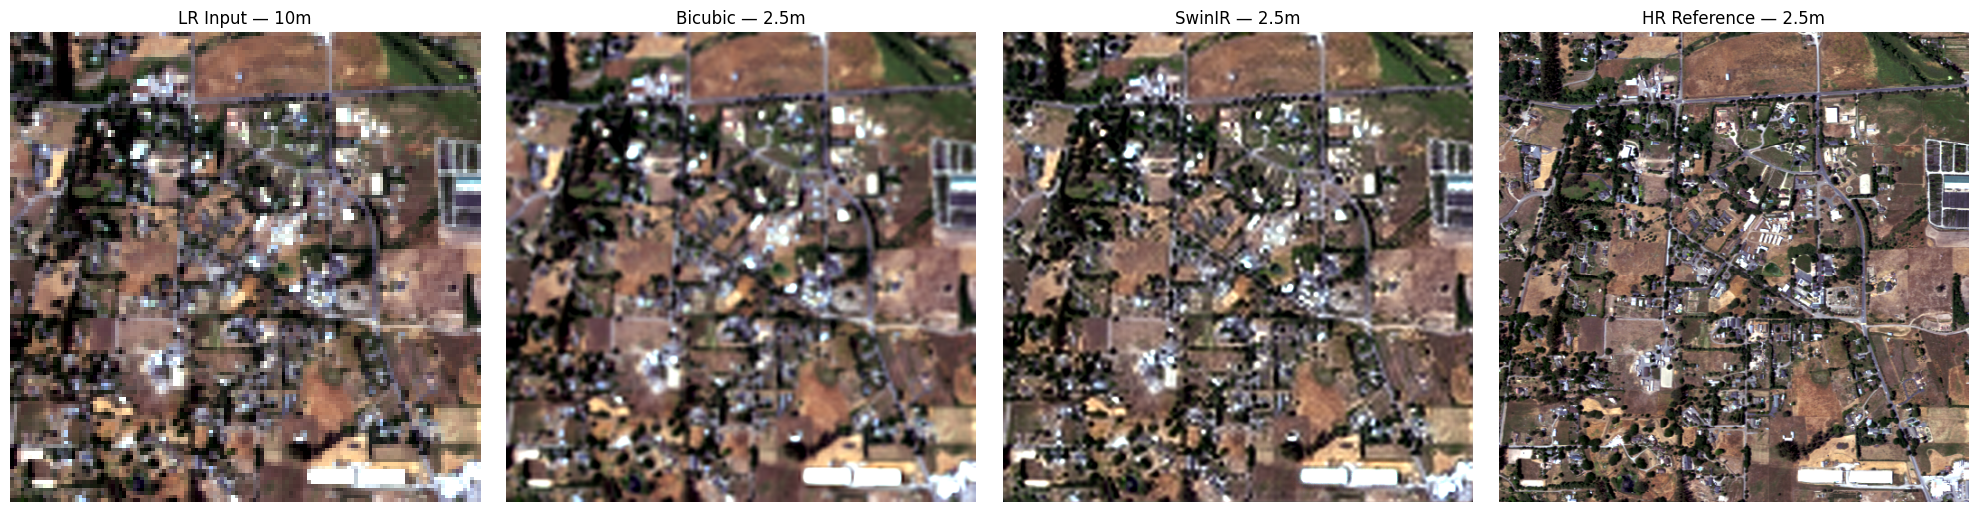

In [63]:
i = 0

lr = test_pairs_swin[i][0]
hr = swin_targets[i]
sr = swin_predictions[i]

lr_tensor = torch.tensor(
    lr,
    dtype=torch.float32
).unsqueeze(0)

bicubic = F.interpolate(
    lr_tensor,
    size=hr.shape[-2:],
    mode="bicubic",
    align_corners=False
)[0].numpy()

plt.figure(
    figsize=(20, 5)
)

plt.subplot(1, 4, 1)

plt.imshow(
    stretch_rgb(lr)
)

plt.title(
    "LR Input — 10m"
)

plt.axis("off")


plt.subplot(1, 4, 2)

plt.imshow(
    stretch_rgb(bicubic)
)

plt.title(
    "Bicubic — 2.5m"
)

plt.axis("off")


plt.subplot(1, 4, 3)

plt.imshow(
    stretch_rgb(sr)
)

plt.title(
    "SwinIR — 2.5m"
)

plt.axis("off")


plt.subplot(1, 4, 4)

plt.imshow(
    stretch_rgb(hr)
)

plt.title(
    "HR Reference — 2.5m"
)

plt.axis("off")


plt.tight_layout()
plt.show()

## SwinIR Notebook — Short Notes

* **SwinIR:** Transformer-based image restoration/super-resolution model.
* **Input:** 4-band Sentinel-2 image.
* **Output:** 4-band ×4 super-resolved image.
* **Main mechanism:** **Window Attention + Shifted-Window Attention**.
* **Window Attention:** Learns relationships between features inside local windows.
* **Shifted Windows:** Moves the windows between blocks so neighboring windows can exchange information.
* **Loss used:**

  * **Charbonnier Loss** → pixel fidelity
  * **Edge Loss** → preserves boundaries/details
  * **Spectral Angle Loss** → preserves multispectral relationships
* **VGG/Perceptual loss:** ❌ Not used.
* **Training:** AdamW + Cosine Annealing.
* **Result:** SwinIR-only performed worse than Improved RCAN.
* **Conclusion:** For our current dataset, **RCAN + spectral/edge-aware losses is more effective than Transformer-based alternatives**.

### Key experiment result

```text
Improved RCAN
PSNR : 25.127 dB
RMSE : 0.05542
SSIM : 0.6908

SwinIR Only
PSNR : 23.452 dB
RMSE : 0.06721
SSIM : 0.6958
```

**Takeaway:** SwinIR slightly improves SSIM, but sacrifices too much **pixel/radiometric accuracy**, making Improved RCAN the better choice for this satellite SR task.

Now we can move to **tuning Improved RCAN** rather than adding another architecture.
